In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from scipy import stats

## EDA AND SCIKIT-LEARN

In [11]:
tt_df = sns.load_dataset('titanic')
print(tt_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [12]:
print(tt_df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


<Axes: >

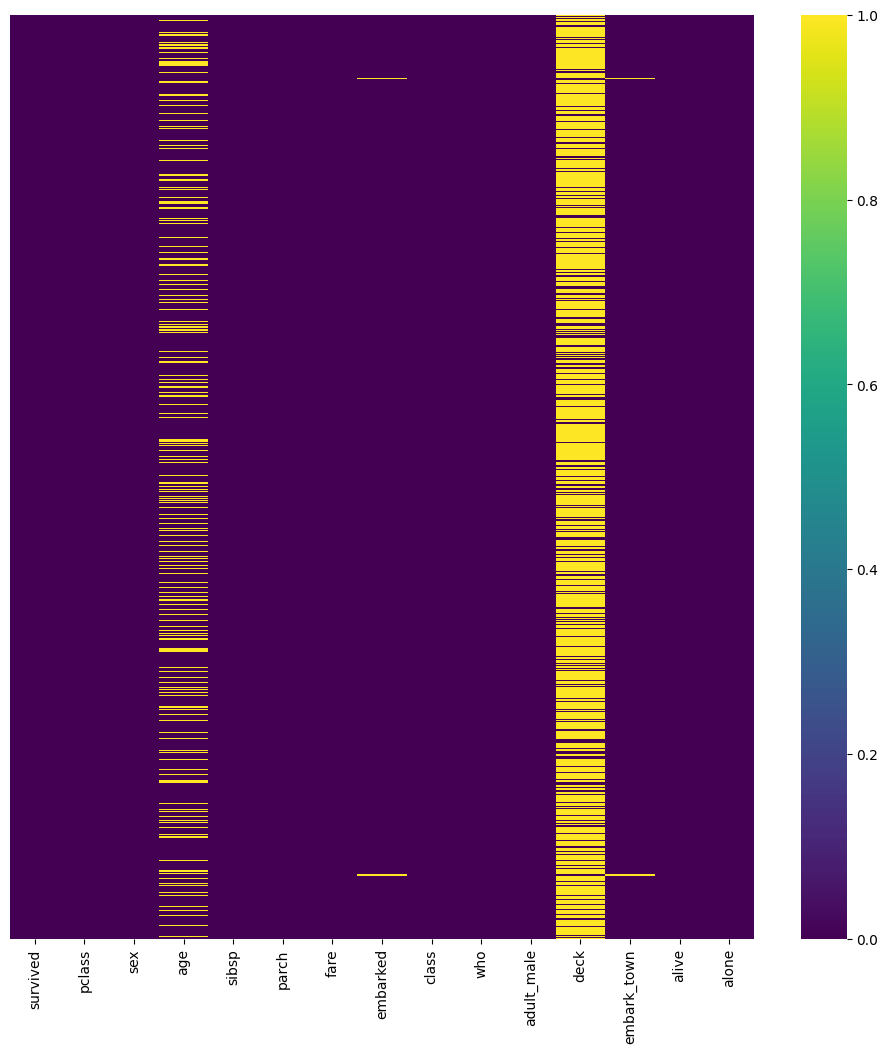

In [13]:
plt.figure(figsize=(12,12))
sns.heatmap(tt_df.isna(),yticklabels=False,cmap='viridis')

In [14]:
## We see that cols deck is almost null or empty. Can't be filled or handled. Hence, drop it completely!
tt_df.drop(['deck','age'],axis=1,inplace=True)

<Axes: >

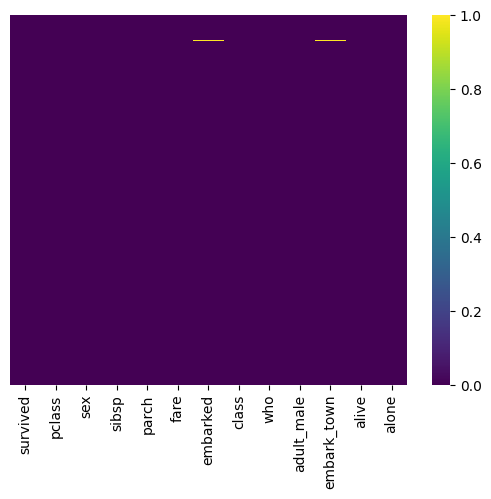

In [15]:
sns.heatmap(tt_df.isna(),cmap='viridis',yticklabels=False)

In [16]:
## We observe that there are very few empty values in column class and embark_town.
## We can either remove the rows or assign a value.

def handling_missing_val(types):
  if types.casefold() == 'mode':
    tt_df['embarked'] = tt_df['embarked'].fillna(tt_df['embarked'].mode()[0])
  elif types.casefold() == 'analysis':
    missing_df = pd.DataFrame(tt_df.loc[tt_df.loc[:,'embarked'].isna() == True,'fare'])
    missing_df['index'] = tt_df.loc[tt_df.loc[:,'embarked'].isna() == True,'fare'].index.tolist()
    missing_df.index = range(missing_df.shape[0])
    print(missing_df)
    median_fare_for_each_class = [int(tt_df.loc[tt_df.loc[:,'pclass']==class_no,'fare'].mean()) for class_no in range(1,4)]
    print(median_fare_for_each_class)
    ## We see that that the man's fare is very close to mean fare price of 1st class!. Assign embarked and embarked_town from mode of first class
    for index in range(tt_df.shape[0]):
      tt_df.loc[index,'embarked'] = tt_df.loc[tt_df.loc[:,'pclass'] == 1,'embarked'].mode()[0]
      tt_df.loc[index,'embark_town'] = tt_df.loc[tt_df.loc[:,'pclass'] == 1,'embark_town'].mode()[0]



In [18]:
## In this cell :- 1) You will see the person's ticket fare (whose embark_town and embarked entry is missing)
##                 2) The mean fare for each class (there were 3 classes in titanic. Namely, 1st, 2nd and 3rd).
handling_missing_val('Analysis')

Empty DataFrame
Columns: [fare, index]
Index: []
[84, 20, 13]


<Axes: >

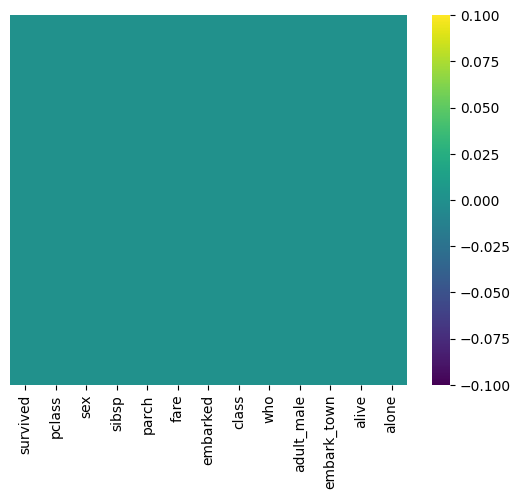

In [19]:
sns.heatmap(tt_df.isnull(),cmap='viridis',yticklabels=False)

<Axes: xlabel='alive', ylabel='count'>

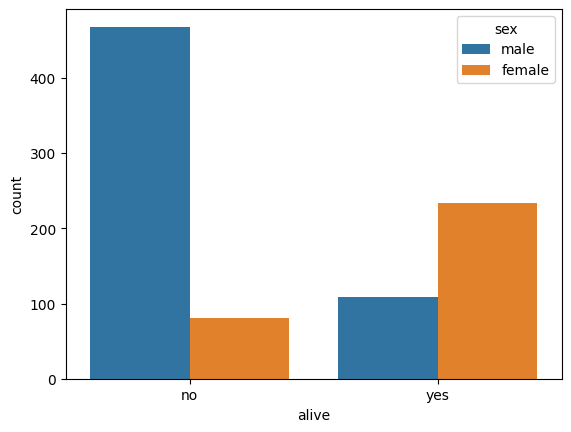

In [21]:
sns.countplot(tt_df,x='alive',hue='sex')

(0.0, 100.0)

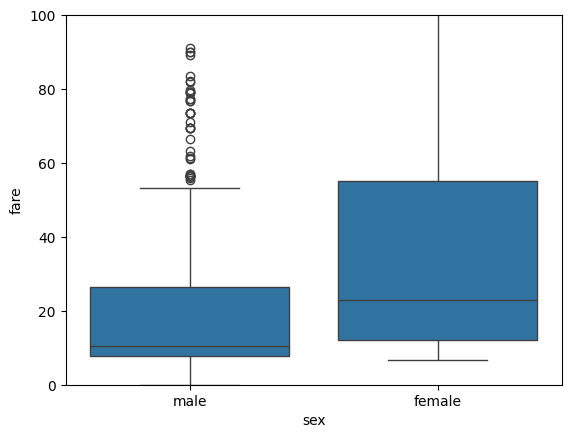

In [ ]:
sns.boxplot(data=tt_df,x='sex',y='fare')
plt.ylim([0,100])

<Axes: xlabel='sex', ylabel='alone'>

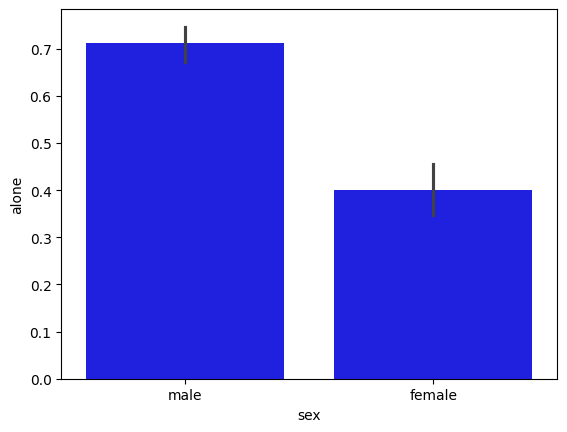

In [23]:
sns.barplot(data=tt_df,x='sex',y='alone',color='blue')

(0.0, 150.0)

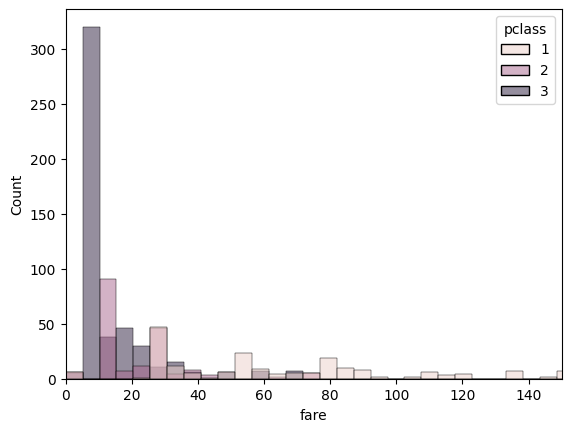

In [25]:
# sns.histplot(data=tt_df,x='fare',hue='pclass')
sns.histplot(data=tt_df,x='fare',hue='pclass',bins=100)
plt.xlim([0,150])

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=102)
print("Before Split : \n",X.shape,y.shape,'\n'*2,"After Split : \n",X_train.shape,X_test.shape,y_train.shape,y_test.shape)

Before Split : 
 (150, 4) (150,) 

 After Split : 
 (120, 4) (30, 4) (120,) (30,)


Normalization Methods

In [ ]:
def normalization(norm_type,train_data,test_data,total_data):
  if norm_type.casefold() == 'minmaxscaler':
    ## Math x_norm = (x - x_min)/(x_max - x_min)
    norm_inst = MinMaxScaler(feature_range=(0,1))
    train_data = norm_inst.fit_transform(train_data)
    test_data = norm_inst.transform(test_data)
    print(train_data.min(),train_data.max(),test_data.min(),test_data.max())
  elif norm_type.casefold() == 'zscore':
    ## Math x_norm = (x - mu/std.dev). Good for quick, stats purpose.
    ## Calc mean ans std. dev. on the fly and doesn't store mean and std
    total_data = stats.zscore(total_data)
    print(total_data.mean(),total_data.std())
  elif norm_type.casefold() == 'standardscaler':
    ## Math x_norm = (x - mu/std.dev). Built primarily for data-preprocessing pipeline.
    ## Stores the mean and std. dev.
    norm_inst = StandardScaler()
    norm_inst.fit(train_data)
    train_data = norm_inst.transform(train_data)
    test_data = norm_inst.transform(test_data)
    print(norm_inst.mean_,norm_inst.scale_)

In [ ]:
normalization('StandardScaler',X_train.copy(),X_test.copy(),X.copy())

[5.835      3.04583333 3.77083333 1.20666667] [0.80297883 0.43356965 1.732599   0.76318776]


# Dimensionality Reduction (PCA, t-SNE and UMAP)

In [26]:
from sklearn.datasets import make_blobs

In [27]:
X, y = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=2.5, random_state=42)

In [28]:
X.shape

(300, 2)

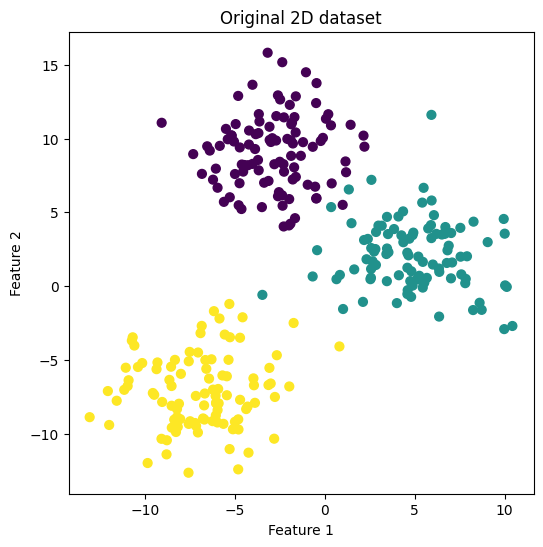

In [29]:
# Visualize the 2D data
plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=40)
plt.title('Original 2D dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### 1D representation of the same data

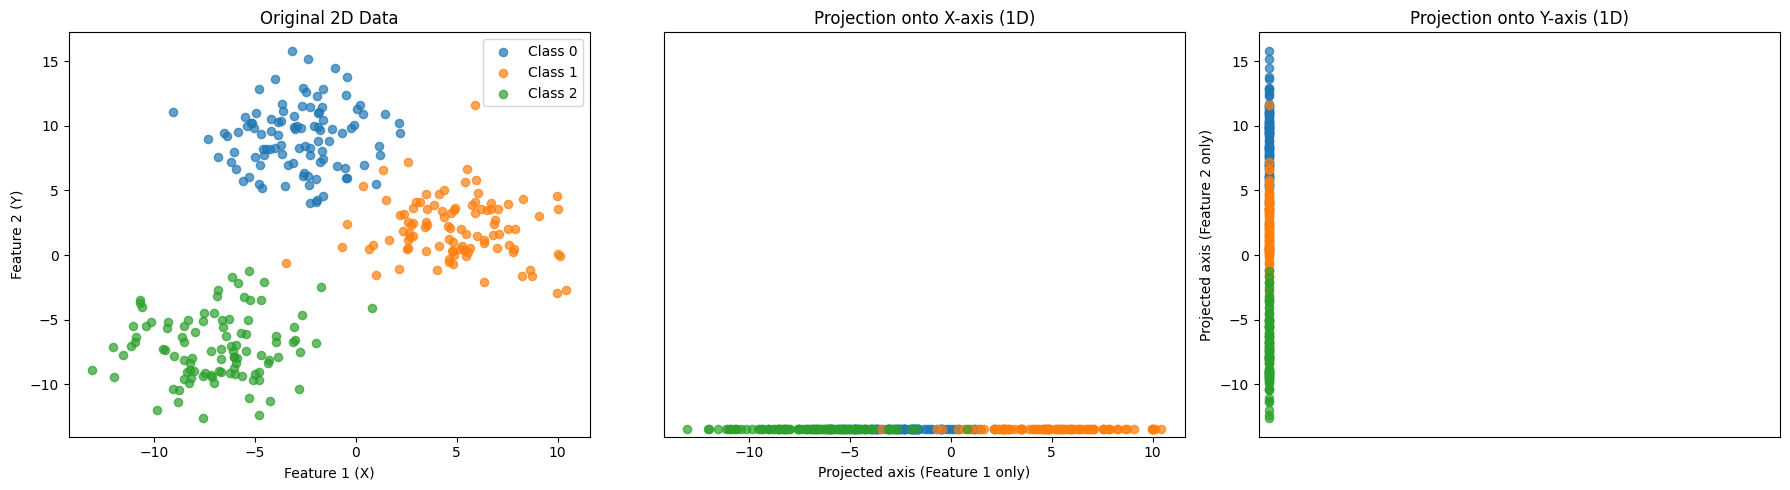

In [30]:
# Project onto the x-axis
x_projection = X[:, 0] # keep only x coord
y_projection = X[:, 1] # Keep only y coord

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

# 2D data
for cls, color in zip(np.unique(y), colors):
    axes[0].scatter(X[y == cls, 0], X[y == cls, 1], s=35, color=color, alpha=0.7, label=f'Class {cls}')

axes[0].set_title('Original 2D Data')
axes[0].set_xlabel('Feature 1 (X)')
axes[0].set_ylabel('Feature 2 (Y)')
axes[0].legend()

# Projection onto X-axis
for cls, color in zip(np.unique(y), colors):
    axes[1].scatter(x_projection[y == cls], np.zeros(np.sum(y == cls)), s=35, color=color, alpha=0.7)

axes[1].set_title('Projection onto X-axis (1D)')
axes[1].set_xlabel('Projected axis (Feature 1 only)')
axes[1].set_yticks([])
axes[1].set_ylim(-0.01, 0.5)

# Projection onto Y-axis
for cls, color in zip(np.unique(y), colors):
    axes[2].scatter(np.zeros(np.sum(y == cls)), y_projection[y == cls], s=35, color=color, alpha=0.7)

axes[2].set_title('Projection onto Y-axis (1D)')
axes[2].set_ylabel('Projected axis (Feature 2 only)')
axes[2].set_xticks([])
axes[2].set_xlim(-0.01, 0.5)

plt.tight_layout()
plt.show()


### Use PCA for the linear projection
Instead of choosing Feature 1 or 2 manually, PCA chooses the direction of maximum variance.

Explained variance ratio: 0.7104816870390097 



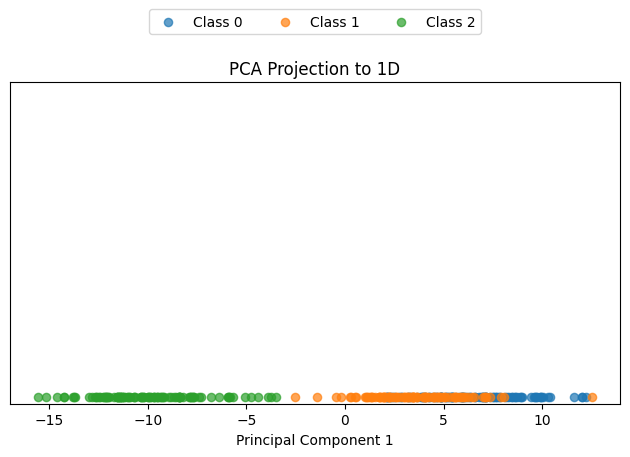

In [31]:
from sklearn.decomposition import PCA

pca_1d = PCA(n_components=2)
X_pca1 = pca_1d.fit_transform(X)

for cls, color in zip(np.unique(y), colors):
    plt.scatter(X_pca1[y == cls, 0], np.zeros(np.sum(y == cls)), s=35, color=color, alpha=0.7, label=f'Class {cls}')

plt.yticks([])
plt.ylim(-0.01, 0.5)
plt.xlabel('Principal Component 1')
plt.title('PCA Projection to 1D')
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.25))

print('Explained variance ratio:', pca_1d.explained_variance_ratio_[0], '\n')

plt.tight_layout()
plt.show()

- Instead of projecting onto the original x-axis, it projects onto the direction that captures the largest spread of the data.

However, PCA is still linear.
If classes are arranged in a nonlinear shape, PCA cannot untangle them.

### Non- Linear dataset

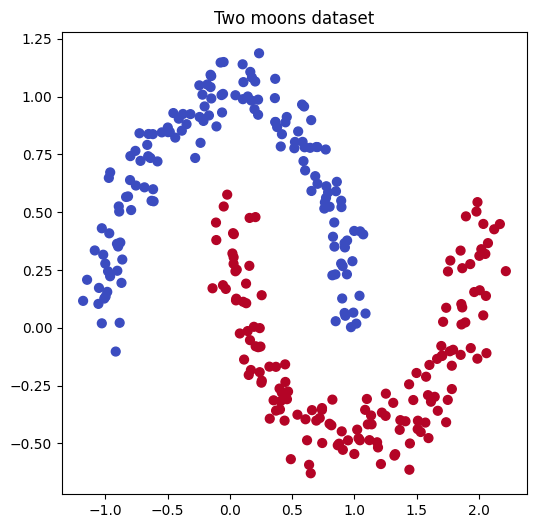

In [32]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=300, noise=0.08, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap='coolwarm', s=40)
plt.title('Two moons dataset')
plt.show()

classes are intertwined

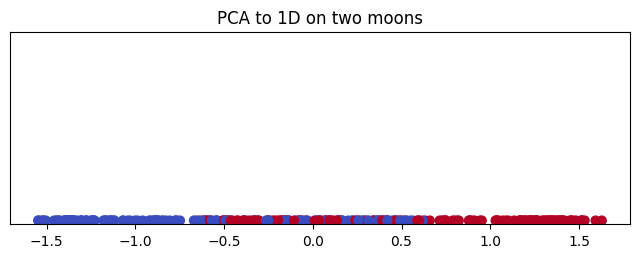

In [33]:
# Lets apply PCA
X_moon_pca = PCA(n_components=1).fit_transform(X_moon)

plt.figure(figsize=(8,2.5))
plt.scatter(X_moon_pca[:,0], np.zeros_like(X_moon_pca[:,0]), c=y_moon, cmap='coolwarm', s=40)
plt.yticks([])
plt.ylim(-0.01, 0.5)
plt.title('PCA to 1D on two moons')
plt.show()

- Heavy overlap
- Poor class separation

This happens because PCA can only use straight lines.

### t-SNE (t-distributed Stochastic Neighbor Embedding)
How t-SNE is different from PCA?
- t-SNE asks which points are neighbour?
- If two points are close in the original space (higher dimension), keep them close in embedding (lower dimension)
- If two points are far apart, try to keep them far apart.



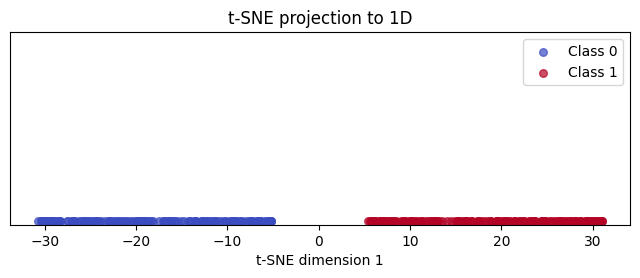

In [34]:
from sklearn.manifold import TSNE

tsne_1d = TSNE(n_components=1, perplexity=30, random_state=42, init='pca')
X_tsne1 = tsne_1d.fit_transform(X_moon)

plt.figure(figsize=(8,2.5))

colors = plt.cm.coolwarm(np.linspace(0, 1, len(np.unique(y_moon))))

for cls, color in zip(np.unique(y_moon), colors):
    plt.scatter(
        X_tsne1[y_moon == cls, 0],
        np.zeros(np.sum(y_moon == cls)),
        color=color,
        s=30,
        alpha=0.7,
        label=f'Class {cls}'
    )

plt.yticks([])
plt.ylim(-0.01, 0.5)
plt.xlabel('t-SNE dimension 1')
plt.title('t-SNE projection to 1D')
plt.legend()
plt.show()

- A dense, tight cluster in lower dimesnion does not mean the cluster was densein high-dimensional space.
- Inter-Cluster distance does not accurately reflect Eucledian distance in original space.


### Let's see higher dimension example

In [35]:
from sklearn.datasets import load_digits
import umap

In [36]:
# Load the Digits Dataset (64 Pixels)
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

In [37]:
images.shape, X.shape

((1797, 8, 8), (1797, 64))

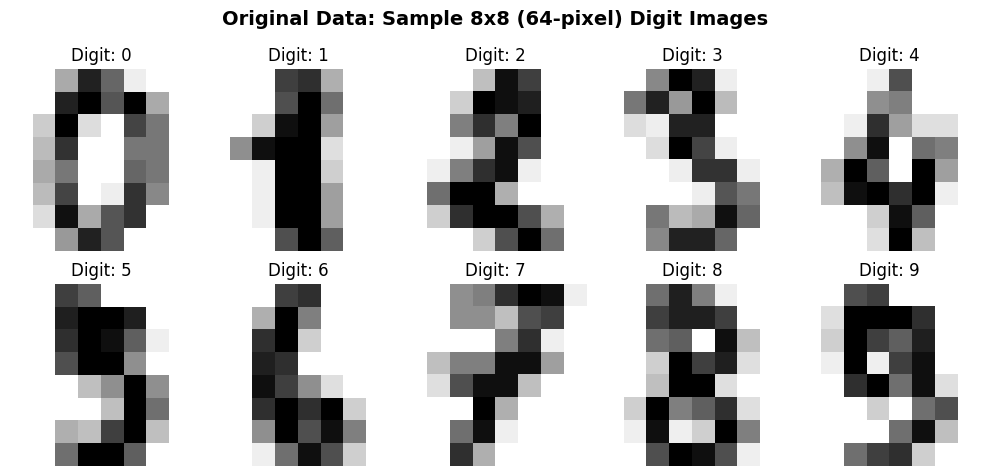

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Original Data: Sample 8x8 (64-pixel) Digit Images", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(label=f"Digit: {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print("Computing PCA projection...")
pca_res = PCA(n_components=2, random_state=42).fit_transform(X)

print("Computing t-SNE projection...")
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1).fit_transform(X)

print("Computing UMAP projection...")
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

Computing PCA projection...
Computing t-SNE projection...
Computing UMAP projection...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


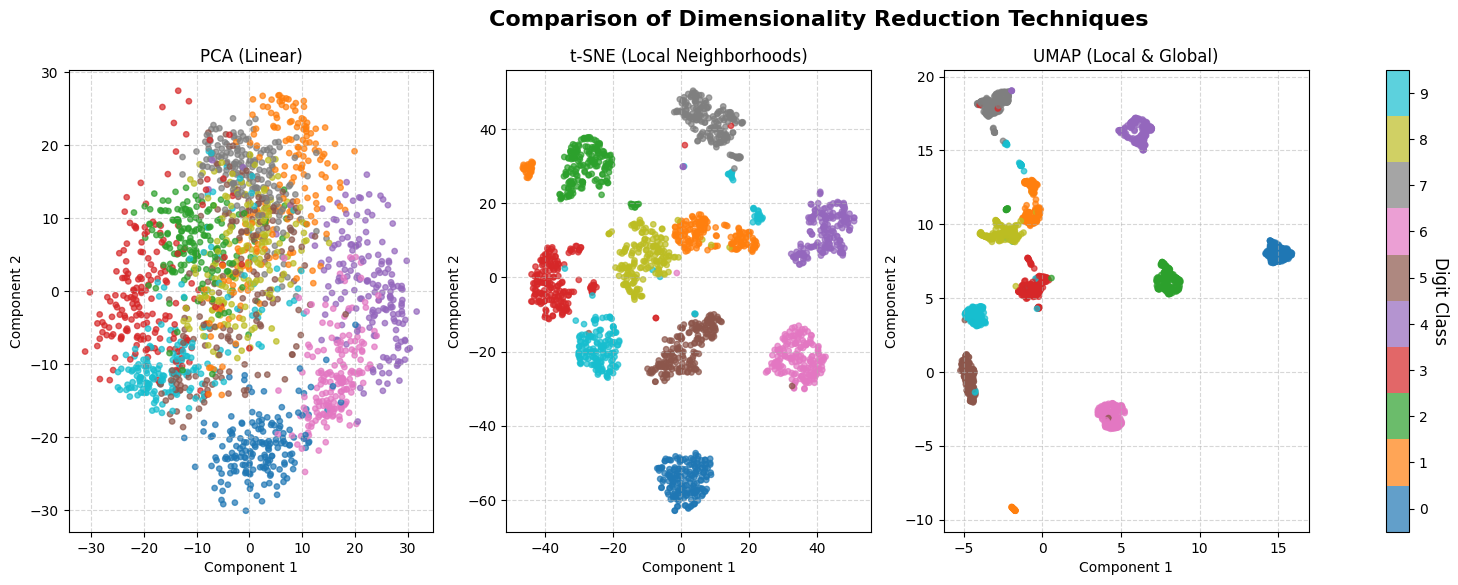

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle("Comparison of Dimensionality Reduction Techniques", fontsize=16, fontweight='bold')

methods = [
    ("PCA (Linear)", pca_res),
    ("t-SNE (Local Neighborhoods)", tsne_res),
    ("UMAP (Local & Global)", umap_res)
]

scatter_kwargs = {'c': y, 'cmap': 'tab10', 's': 15, 'alpha': 0.7}

for idx, (title, coordinates) in enumerate(methods):
    scatter = axs[idx].scatter(coordinates[:, 0], coordinates[:, 1], **scatter_kwargs)
    axs[idx].set_title(title, fontsize=12)
    axs[idx].set_xlabel("Component 1")
    axs[idx].set_ylabel("Component 2")
    axs[idx].grid(True, linestyle='--', alpha=0.5)

cbar = fig.colorbar(scatter, ax=axs.ravel().tolist(), boundaries=np.arange(11)-0.5, ticks=np.arange(10))
cbar.set_label("Digit Class", rotation=270, labelpad=15, fontsize=12)

plt.show()

- In PCA, the clusters show massive overlap.
- In t-SNE, tightly packed and distinct clusters, distances seperating clusters are arbitrary
- In UMAP, similar distinct cluster, but groups with structural topologies align nearer to each other.

### Hyperparameters caveats

### t-SNE

Computing t-SNE with perplexity=5...
Computing t-SNE with perplexity=30...
Computing t-SNE with perplexity=50...


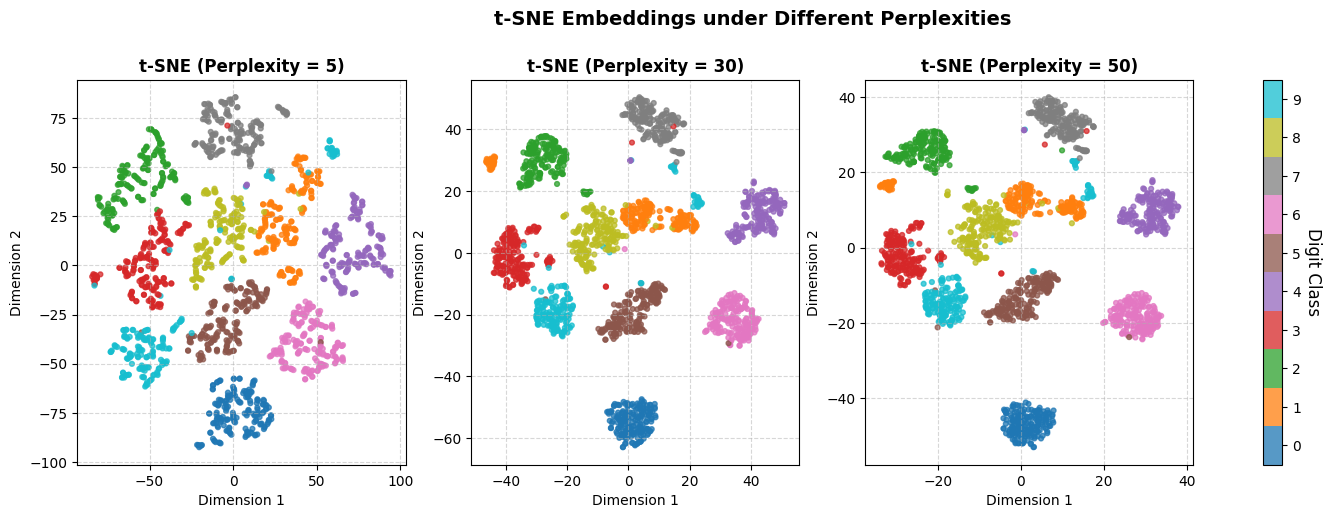

In [38]:
perplexities = [5, 30, 50]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate(perplexities):
    print(f"Computing t-SNE with perplexity={perp}...")

    tsne_res = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        n_jobs=-1
    ).fit_transform(X)

    scatter = axs[i].scatter(
        tsne_res[:, 0],
        tsne_res[:, 1],
        c=y,
        cmap='tab10',
        s=12,
        alpha=0.75
    )
    axs[i].set_title(f"t-SNE (Perplexity = {perp})", fontsize=12, fontweight='bold')
    axs[i].set_xlabel("Dimension 1")
    axs[i].set_ylabel("Dimension 2")
    axs[i].grid(True, linestyle='--', alpha=0.5)

cbar = fig.colorbar(
    scatter,
    ax=axs.tolist(),
    boundaries=np.arange(11)-0.5,
    ticks=np.arange(10)
)
cbar.set_label("Digit Class", rotation=270, labelpad=15, fontsize=12)

# 6. Final display adjustments
plt.suptitle("t-SNE Embeddings under Different Perplexities", fontsize=14, fontweight='bold', y=1.02)
plt.show()

perplexity:
- low(=5): very local, many small clusters
- standard(=30):
    - the images clump together cleanly by there digits.
    - cluster match there actual classes.
- high(=50): more global organization


### UMAP

Computing UMAP with n_neighbors=5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP with n_neighbors=15...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP with n_neighbors=50...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


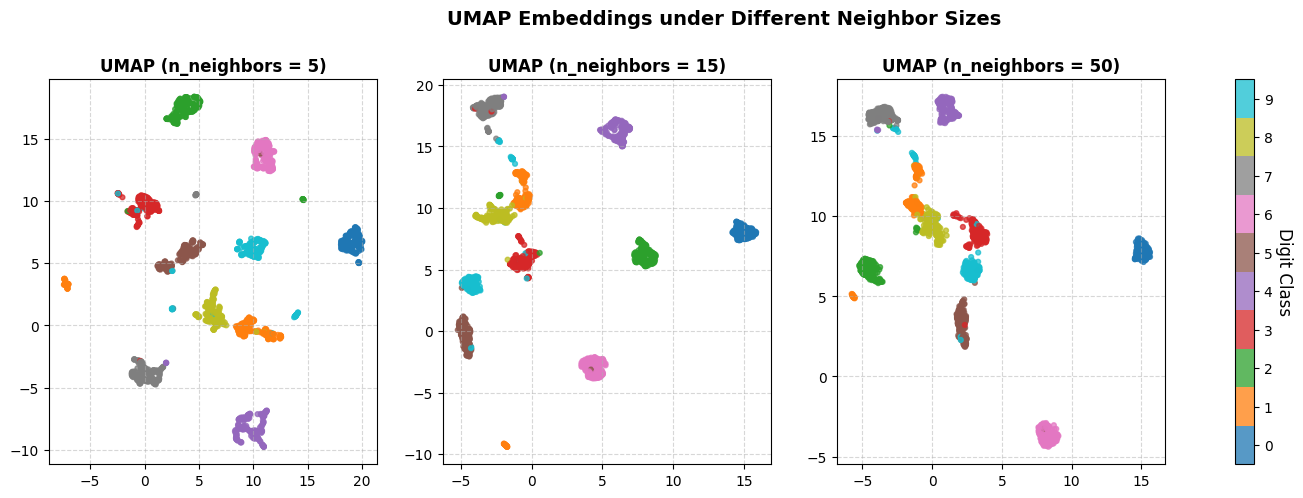

In [39]:
neighbors_list = [5, 15, 50]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, n_nb in enumerate(neighbors_list):
    print(f"Computing UMAP with n_neighbors={n_nb}...")
    # min_dist keeps local structure tight
    umap_res = umap.UMAP(n_neighbors=n_nb, min_dist=0.1, random_state=42).fit_transform(X)

    scatter = axs[i].scatter(umap_res[:, 0], umap_res[:, 1], c=y, cmap='tab10', s=12, alpha=0.75)
    axs[i].set_title(f"UMAP (n_neighbors = {n_nb})", fontsize=12, fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.5)

cbar = fig.colorbar(scatter, ax=axs.tolist(), boundaries=np.arange(11)-0.5, ticks=np.arange(10))
cbar.set_label("Digit Class", rotation=270, labelpad=15, fontsize=12)

plt.suptitle("UMAP Embeddings under Different Neighbor Sizes", fontsize=14, fontweight='bold', y=1.02)
plt.show()

n_neighbors:
- low(=5): Emphasizes local detail
- standard(=15): balanced
- high(=50): more global structure
